In [46]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

In [2]:
climate_change_data = pd.read_csv("data/climate_change_dataset.csv")

In [3]:
climate_change_data = climate_change_data.rename(columns = {'Avg Temperature (°C)': 'Avg_Temperature', 'CO2 Emissions (Tons/Capita)': 'CO2_Emissions', 'Sea Level Rise (mm)': 'Sea_Level_Rise', 'Rainfall (mm)': 'Rainfall', 'Renewable Energy (%)': 'Renewable_Energy', 'Extreme Weather Events':  'Extreme_Weather_Events', 'Forest Area (%)': 'Forest_Area'})

In [4]:
climate_change_data.columns

Index(['Year', 'Country', 'Avg_Temperature', 'CO2_Emissions', 'Sea_Level_Rise',
       'Rainfall', 'Population', 'Renewable_Energy', 'Extreme_Weather_Events',
       'Forest_Area'],
      dtype='object')

In [7]:
climate_change_data = climate_change_data.drop_duplicates(subset = ['Year', 'Country'])

In [8]:
climate_change_data_2023 = climate_change_data[climate_change_data.Year == 2023]
top_three_poluters_2023 = climate_change_data_2023.loc[climate_change_data_2023.CO2_Emissions.nlargest(3).index]
top_three_clean_2023 = climate_change_data_2023.loc[climate_change_data_2023.CO2_Emissions.nsmallest(3).index]

In [9]:
top_three_poluters_2023

,Year,Country,Avg_Temperature,CO2_Emissions,Sea_Level_Rise,Rainfall,Population,Renewable_Energy,Extreme_Weather_Events,Forest_Area
97,2023,USA,6.2,18.6,4.4,1806,487618104,21.9,8,12.1
122,2023,Argentina,30.2,18.1,4.4,2930,542661199,32.7,12,64.1
15,2023,India,31.0,17.6,2.0,2444,365927452,25.1,8,20.6


In [10]:
top_three_clean_2023

,Year,Country,Avg_Temperature,CO2_Emissions,Sea_Level_Rise,Rainfall,Population,Renewable_Energy,Extreme_Weather_Events,Forest_Area
493,2023,Japan,21.9,4.9,3.2,2135,760660662,19.0,11,49.7
203,2023,China,22.5,6.6,3.8,1088,554504868,16.4,13,67.7
281,2023,UK,33.5,9.1,4.2,534,828538833,14.3,10,53.8


In [11]:
# The most poluted country in 2023
usa_data = climate_change_data[climate_change_data.Country == "USA"]
usa_data = usa_data.sort_values(by = "Year")
# The least pluted country in 2023
japan_data = climate_change_data[climate_change_data.Country == "Japan"]
japan_data = japan_data.sort_values(by = "Year")

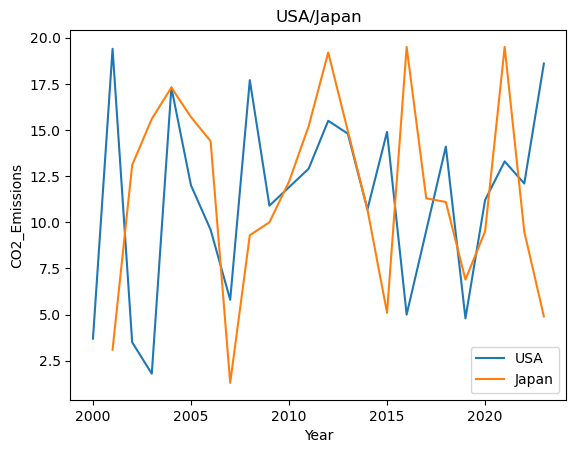

In [12]:
# There is no trend of constantly increasing CO2 emissions neither for most polluted country nor nor for least polluted
plt.plot(usa_data.Year, usa_data.CO2_Emissions, label = "USA")
plt.plot(japan_data.Year, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Year")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

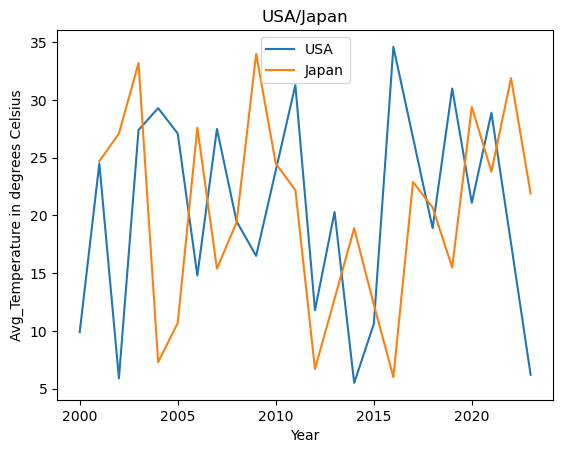

In [33]:
# No increasing trend of average temperature
plt.plot(usa_data.Year, usa_data.Avg_Temperature, label = "USA")
plt.plot(japan_data.Year, japan_data.Avg_Temperature, label = "Japan")
plt.xlabel("Year")
plt.ylabel("Avg_Temperature in degrees Celsius")
plt.title("USA/Japan")
plt.legend()
plt.show()

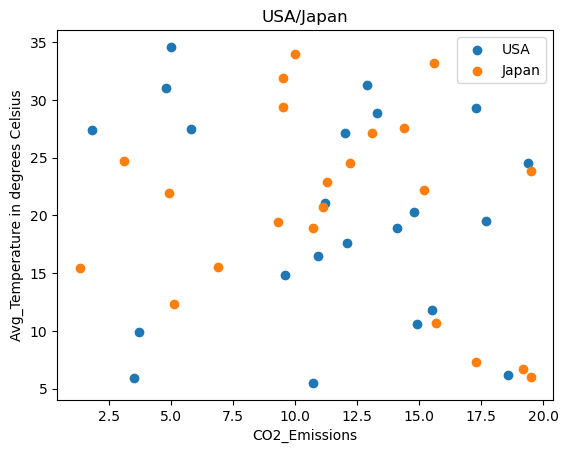

In [32]:
plt.scatter(usa_data.CO2_Emissions, usa_data.Avg_Temperature, label = "USA")
plt.scatter(japan_data.CO2_Emissions, japan_data.Avg_Temperature, label = "Japan")
plt.xlabel("CO2_Emissions")
plt.ylabel("Avg_Temperature in degrees Celsius")
plt.title("USA/Japan")
plt.legend()
plt.show()

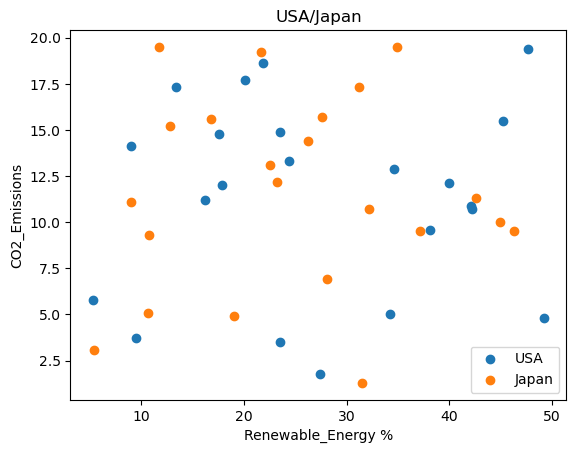

In [30]:
plt.scatter(usa_data.Renewable_Energy, usa_data.CO2_Emissions, label = "USA")
plt.scatter(japan_data.Renewable_Energy, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Renewable_Energy %")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

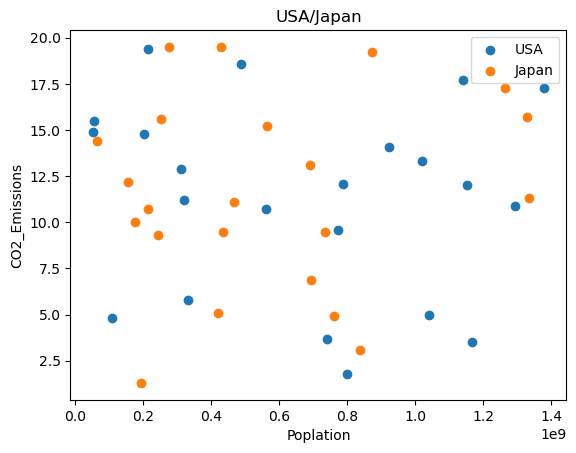

In [18]:
plt.scatter(usa_data.Population, usa_data.CO2_Emissions, label = "USA")
plt.scatter(japan_data.Population, japan_data.CO2_Emissions, label = "Japan")
plt.xlabel("Poplation")
plt.ylabel("CO2_Emissions")
plt.title("USA/Japan")
plt.legend()
plt.show()

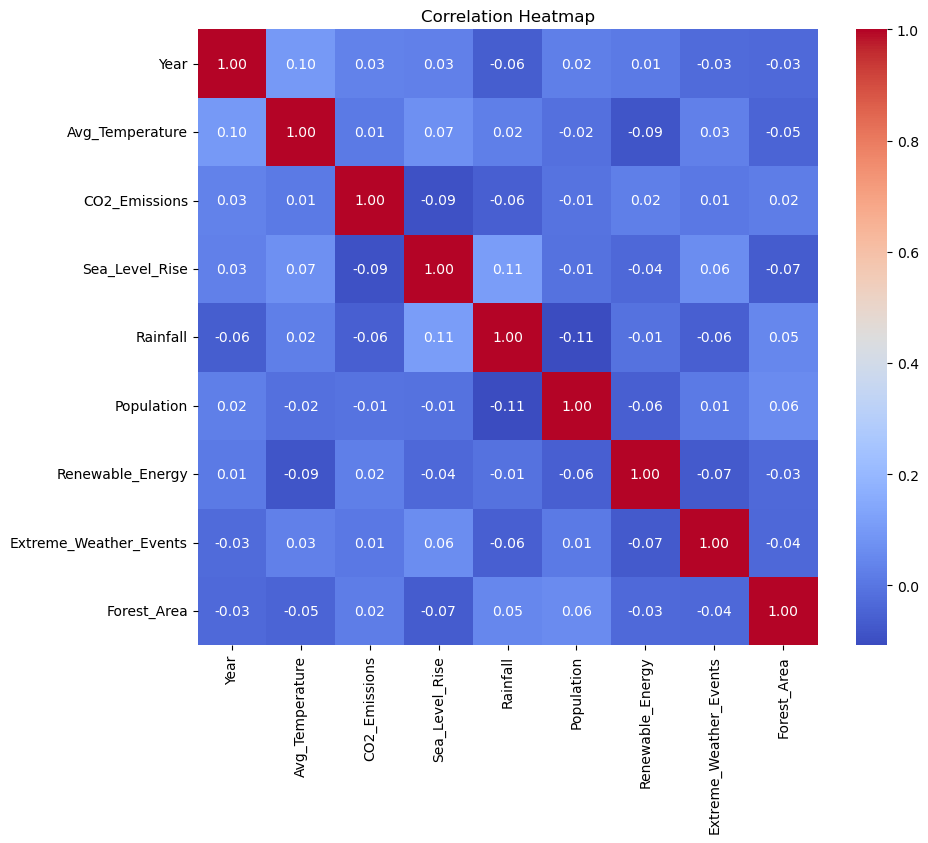

In [45]:
numeric_df = climate_change_data.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.dropna()
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(),  annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()